# TASK 04 — Local Minima and Convexity

In this task, I will investigate the difference between local and global
minima using a non-convex function.

The function is:

f(x) = x^4 - 4x^2 + 0.4x

Its gradient is:

f'(x) = 4x^3 - 8x + 0.4

This function has two minima:
- a shallow local minimum
- a deeper global minimum

I will run gradient descent from different starting points and observe
how the starting point affects the final result.

I will then compare this with the convex function:

f(x) = (x - 2)^2

## Local Minimum vs Global Minimum

A local minimum is a point that has a lower function value than the
nearby points.

A global minimum is the lowest point across the entire function.

For a function with multiple valleys, gradient descent may enter one
valley and stop at its local minimum instead of reaching the deeper
global minimum.

This is why the starting point can matter for non-convex functions.

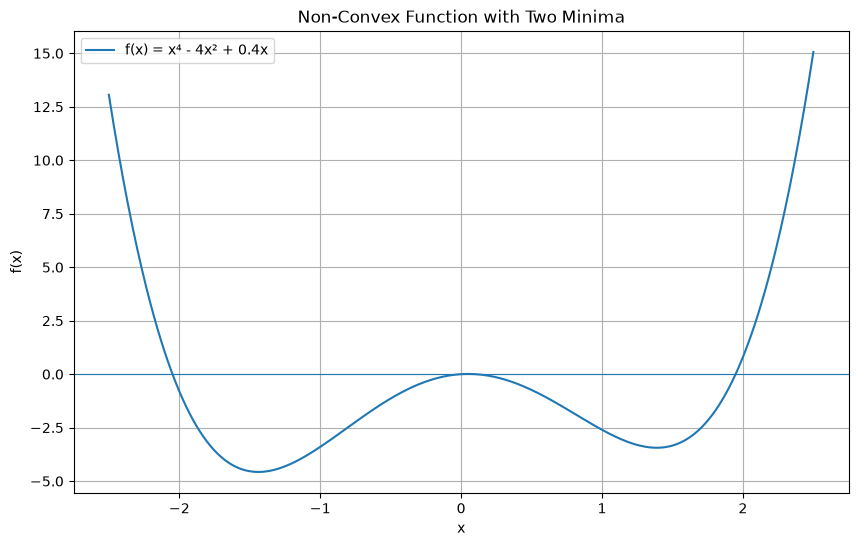

NON-CONVEX FUNCTION
Start:  -2.0 -> End: x =  -1.4386, f(x) =  -4.5706
Start:  -0.5 -> End: x =  -1.4386, f(x) =  -4.5706
Start:   0.5 -> End: x =   1.3885, f(x) =  -3.4394
Start:   2.2 -> End: x =   1.3885, f(x) =  -3.4394


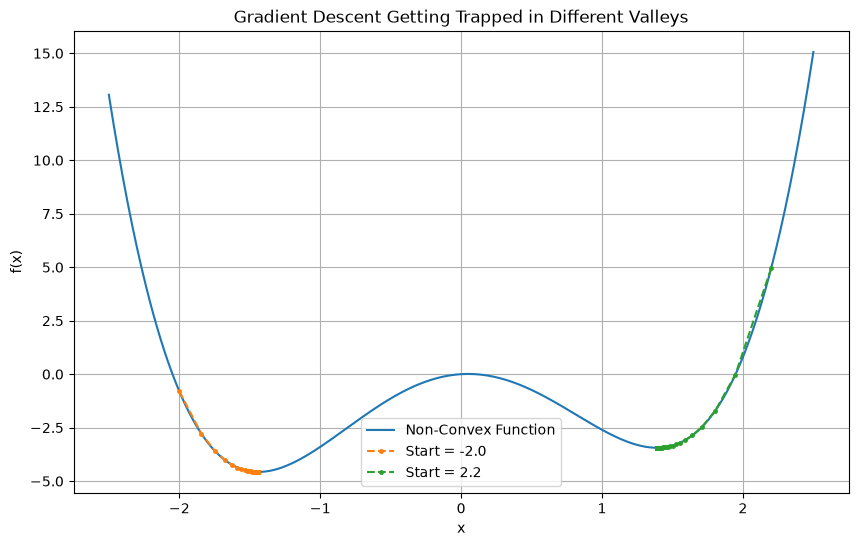


DESCENT PATH ENDPOINTS
Start  -2.0 -> End -1.438580, Loss = -4.570600
Start   2.2 -> End 1.388517, Loss = -3.439406


CONVEX FUNCTION
Start:   -5.0 -> End: x = 1.999989, f(x) = 0.00000000
Start:   -1.0 -> End: x = 1.999995, f(x) = 0.00000000
Start:    0.0 -> End: x = 1.999997, f(x) = 0.00000000
Start:    5.0 -> End: x = 2.000005, f(x) = 0.00000000
Start:   10.0 -> End: x = 2.000012, f(x) = 0.00000000


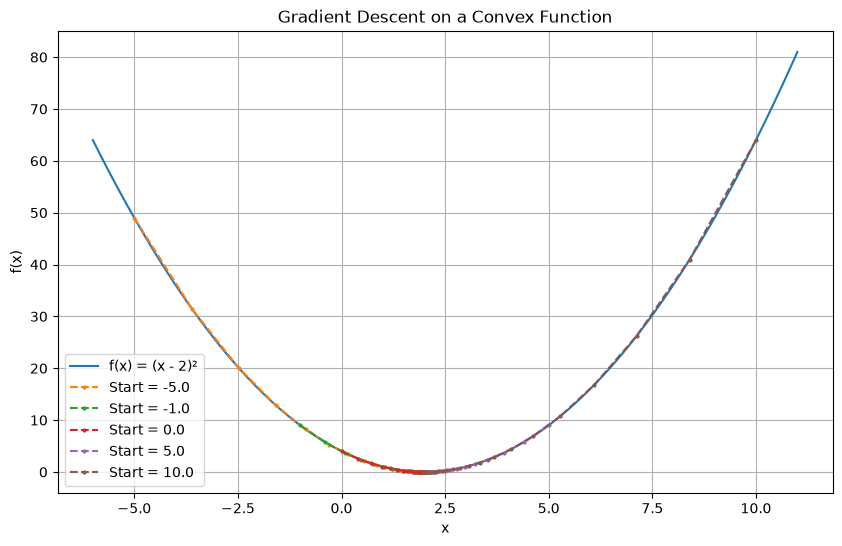


FINAL SUMMARY
Non-convex function:
Different starting points can reach different minima.

Convex function:
Different starting points converge to the same minimum.

Known convex minimum:
x = 2


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reusable Gradient Descent

def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x)
        history.append(x)

    return np.array(history)

# PART 1 — Non-Convex Function

def f(x):
    return x**4 - 4*x**2 + 0.4*x


def grad(x):
    return 4*x**3 - 8*x + 0.4

# Plot the non-convex function

x_values = np.linspace(-2.5, 2.5, 600)
y_values = f(x_values)

plt.figure(figsize=(10, 6))

plt.plot(
    x_values,
    y_values,
    label="f(x) = x⁴ - 4x² + 0.4x"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Non-Convex Function with Two Minima")
plt.grid(True)
plt.legend()

plt.show()

# Run Gradient Descent from Several Starting Points

starts = [-2.0, -0.5, 0.5, 2.2]

lr = 0.01
steps = 200

print("NON-CONVEX FUNCTION")
print("=" * 55)

paths = {}

for start in starts:

    path = gradient_descent(
        grad_fn=grad,
        start=start,
        lr=lr,
        steps=steps
    )

    paths[start] = path

    final_x = path[-1]
    final_y = f(final_x)

    print(
        f"Start: {start:>5.1f} "
        f"-> End: x = {final_x:>8.4f}, "
        f"f(x) = {final_y:>8.4f}"
    )

# Plot Two Descent Paths

plt.figure(figsize=(10, 6))

plt.plot(
    x_values,
    y_values,
    label="Non-Convex Function"
)

# Two starts that reach different valleys
path_left = paths[-2.0]
path_right = paths[2.2]

plt.plot(
    path_left,
    f(path_left),
    marker="o",
    markersize=2.5,
    linestyle="--",
    label="Start = -2.0"
)

plt.plot(
    path_right,
    f(path_right),
    marker="o",
    markersize=2.5,
    linestyle="--",
    label="Start = 2.2"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent Getting Trapped in Different Valleys")
plt.grid(True)
plt.legend()

plt.show()

# Print Endpoints

print("\nDESCENT PATH ENDPOINTS")
print("=" * 55)

for start in [-2.0, 2.2]:

    path = paths[start]

    print(
        f"Start {start:>5.1f} "
        f"-> End {path[-1]:.6f}, "
        f"Loss = {f(path[-1]):.6f}"
    )

# PART 2 — Convex Function

def convex_f(x):
    return (x - 2) ** 2


def convex_grad(x):
    return 2 * (x - 2)


convex_starts = [-5.0, -1.0, 0.0, 5.0, 10.0]

convex_paths = {}

print("\n\nCONVEX FUNCTION")
print("=" * 55)

for start in convex_starts:

    path = gradient_descent(
        grad_fn=convex_grad,
        start=start,
        lr=0.1,
        steps=60
    )

    convex_paths[start] = path

    print(
        f"Start: {start:>6.1f} "
        f"-> End: x = {path[-1]:>8.6f}, "
        f"f(x) = {convex_f(path[-1]):.8f}"
    )

# Plot Convex Function and All Descent Paths

x_convex = np.linspace(-6, 11, 500)
y_convex = convex_f(x_convex)

plt.figure(figsize=(10, 6))

plt.plot(
    x_convex,
    y_convex,
    label="f(x) = (x - 2)²"
)

for start, path in convex_paths.items():

    plt.plot(
        path,
        convex_f(path),
        marker="o",
        markersize=2,
        linestyle="--",
        label=f"Start = {start}"
    )

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent on a Convex Function")
plt.grid(True)
plt.legend()
plt.show()

# Final Summary
print("\nFINAL SUMMARY")
print("=" * 55)
print("Non-convex function:")
print("Different starting points can reach different minima.")
print("\nConvex function:")
print("Different starting points converge to the same minimum.")
print("\nKnown convex minimum:")
print("x = 2")

## Observations

For the non-convex function:

f(x) = x^4 - 4x^2 + 0.4x

the graph has two valleys.

Depending on the starting point, gradient descent can enter either
valley and converge to the minimum inside that valley.

Therefore, different starting points can produce different final
solutions.

The deeper valley represents the global minimum, while the other valley
contains a shallow local minimum.

## Why Does Gradient Descent Get Trapped?

At a local minimum, the gradient is zero.

Near the minimum, the function increases in every direction, so there
is no downhill direction for gradient descent to follow.

Therefore, once gradient descent reaches the local minimum, the update
becomes zero and it stops there.

This does not mean that the point is the best solution globally; it is
only the best point in its local neighbourhood.

## Convex Function

Now consider:

f(x) = (x - 2)^2

This function has only one minimum:

x = 2

There are no other valleys or local minima that can trap gradient
descent.

Therefore, starting from different positions should lead to the same
minimum, assuming the learning rate is stable.

## Why Does the Starting Point Matter?

For a non-convex function, multiple valleys and local minima exist, so
the starting point determines which valley gradient descent may enter
and where it can become trapped.

For a convex function, there is only one global minimum, so different
starting points can follow different paths but ultimately converge to
the same solution.

## What Does This Mean for Neural Networks?

Neural-network loss functions are generally non-convex and can contain
many local minima, saddle points, and complicated regions.

This means training can depend on initialization and optimization
choices, and finding the exact global minimum is generally difficult.

In practice, modern optimizers and techniques such as good
initialization, learning-rate schedules, momentum, and stochastic
gradient descent help make training effective.